# Dogs & Cats com Vision Transformer (ViT) 🐶🐱

Este projeto objetiva implementar um classificador de Cães e Gatos, usando um modelo pré-treinado do tipo transformer de visão, com PyTorch da biblioteca Hugging Face Transformers.

### ⭐ Destaques do Projeto:
*   **Modelo:** Vision Transformer (ViT) pré-treinado da Google via Hugging Face.
*   **Framework:** PyTorch para treinamento e inferência.
*   **Dataset:** Amostra balanceada contendo:
    *   **Treino:** 1.002 imagens (501 dogs; 501 cats).
    *   **Teste:** 200 imagens (100 dogs; 100 cats).
*   **Objetivo:** Demonstrar o poder do *transfer learning* em arquiteturas baseadas em Atenção para imagens.

## 1. Preparação dos dados 📦

In [1]:
# Instalar pacotes necessários
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [2]:
# Baixar os datasets (treino) do GitHub
!wget https://raw.githubusercontent.com/JoaoPedro4157/Projetos_1/main/Aula10/dataset_treino.zip



--2026-04-02 14:40:44--  https://raw.githubusercontent.com/JoaoPedro4157/Projetos_1/main/Aula10/dataset_treino.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22990940 (22M) [application/zip]
Saving to: ‘dataset_treino.zip’

dataset_treino.zip  100%[===================>]  21.93M  --.-KB/s    in 0.1s    

2026-04-02 14:40:45 (151 MB/s) - ‘dataset_treino.zip’ saved [22990940/22990940]



In [3]:
# Baixar os datasets (teste) do GitHub
!wget https://raw.githubusercontent.com/JoaoPedro4157/Projetos_1/main/Aula10/dataset_teste.zip

--2026-04-02 14:40:49--  https://raw.githubusercontent.com/JoaoPedro4157/Projetos_1/main/Aula10/dataset_teste.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4536691 (4.3M) [application/zip]
Saving to: ‘dataset_teste.zip’

dataset_teste.zip   100%[===================>]   4.33M  --.-KB/s    in 0.05s   

2026-04-02 14:40:49 (85.6 MB/s) - ‘dataset_teste.zip’ saved [4536691/4536691]



In [4]:
# Descompactar os arquivos (treino) silenciosamente
!unzip -oq dataset_treino.zip

In [5]:
# Descompactar os arquivos (teste) silenciosamente
!unzip -oq dataset_teste.zip

In [6]:
# Listar conteúdo básico para conferência (apenas os primeiros itens)
print("--- Conteúdo do diretório atual ---")
!ls -d */

print("\n--- Amostra do Dataset de Treino ---")
!ls dataset_treino | head -n 5

print("\n--- Amostra do Dataset de Teste ---")
!ls dataset_teste | head -n 5

--- Conteúdo do diretório atual ---
dataset_teste/	dataset_treino/  sample_data/

--- Amostra do Dataset de Treino ---
cats
dogs

--- Amostra do Dataset de Teste ---
100.jpg
101.jpg
102.jpg
103.jpg
104.jpg


✅ Verificando amostras do dataset de treino:


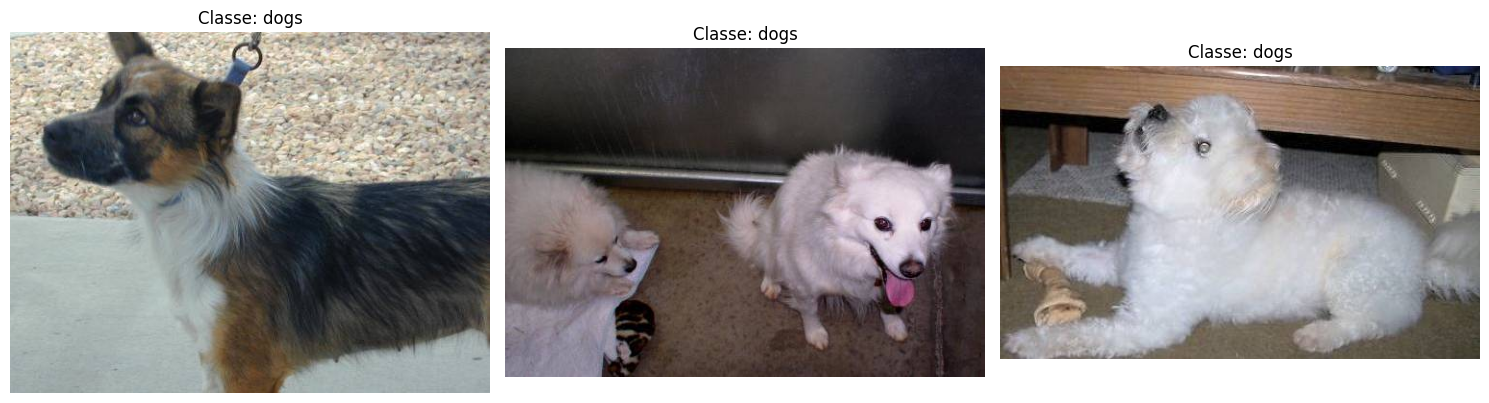

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

def visualizar_amostras(base_path, num_images=3):
    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        chosen_class = random.choice(classes)
        class_path = os.path.join(base_path, chosen_class)
        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Classe: {chosen_class}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("✅ Verificando amostras do dataset de treino:")
visualizar_amostras('./dataset_treino')


In [8]:
# Importação de bibliotecas
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [9]:
# Definir dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Usando dispositivo: {device}')

✅ Usando dispositivo: cuda


In [10]:
# Nome do modelo pré-treinado
model_name = "google/vit-base-patch16-224"

# Carregar processador e modelo
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,                 # 2 classes: gato ou cachorro
    ignore_mismatched_sizes=True  # permite ajustar camadas finais
)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [11]:
# Criar o dataset personalizado
class DogsAndCatsDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        # Pré-processar imagem para o ViT
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze()
        return pixel_values, label

In [12]:
# Dividir o dataset em treino e validação
import torch
from collections import Counter

# Diretório de treino
train_dir = './dataset_treino'

# Criar dataset completo
full_dataset = DogsAndCatsDataset(train_dir, processor)

# Dividir em treino (80%) e validação (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Fixar semente para divisão reproduzível
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

print(f'Total de imagens: {len(full_dataset)}')
print(f'Treinamento: {len(train_dataset)} | Validação: {len(val_dataset)}')

# Descobrir nomes das classes
class_names = full_dataset.dataset.classes
print("Classes encontradas:", class_names)

# Contar quantas imagens de cada classe foram para treino e validação
targets = full_dataset.dataset.targets

train_labels = [targets[i] for i in train_dataset.indices]
val_labels = [targets[i] for i in val_dataset.indices]

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("\nDistribuição no treino:")
for class_idx, class_name in enumerate(class_names):
    print(f" - {class_name}: {train_counts[class_idx]} imagens")

print("\nDistribuição na validação:")
for class_idx, class_name in enumerate(class_names):
    print(f" - {class_name}: {val_counts[class_idx]} imagens")

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

Total de imagens: 1002
Treinamento: 801 | Validação: 201
Classes encontradas: ['cats', 'dogs']

Distribuição no treino:
 - cats: 400 imagens
 - dogs: 401 imagens

Distribuição na validação:
 - cats: 101 imagens
 - dogs: 100 imagens


## 2. Treinamento do Modelo ⚙️

In [13]:
# Treinamento

# Configurações de treino
num_epochs = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Loop de treinamento
for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=images, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=total_loss/(len(progress_bar)),
            accuracy=100.*correct/total
        )

    # Validação
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images, labels=labels)
            val_loss += outputs.loss.item()
            _, predicted = outputs.logits.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"📊 Epoch {epoch+1}/{num_epochs}")
    print(f"  Treino: Loss {total_loss/len(train_loader):.4f} | Acc {100.*correct/total:.2f}%")
    print(f"  Val   : Loss {val_loss/len(val_loader):.4f} | Acc {100.*val_correct/val_total:.2f}%\n")


Epoch 1/10: 100%|██████████| 26/26 [00:28<00:00,  1.10s/it, accuracy=96.5, loss=0.117]


📊 Epoch 1/10
  Treino: Loss 0.1172 | Acc 96.50%
  Val   : Loss 0.0051 | Acc 100.00%



Epoch 2/10: 100%|██████████| 26/26 [00:30<00:00,  1.19s/it, accuracy=100, loss=0.00354]


📊 Epoch 2/10
  Treino: Loss 0.0035 | Acc 100.00%
  Val   : Loss 0.0077 | Acc 100.00%



Epoch 3/10: 100%|██████████| 26/26 [00:29<00:00,  1.13s/it, accuracy=100, loss=0.000994]


...

📊 Epoch 8/10
  Treino: Loss 0.0003 | Acc 100.00%
  Val   : Loss 0.0007 | Acc 100.00%



Epoch 9/10: 100%|██████████| 26/26 [00:30<00:00,  1.17s/it, accuracy=100, loss=0.000223]


📊 Epoch 9/10
  Treino: Loss 0.0002 | Acc 100.00%
  Val   : Loss 0.0006 | Acc 100.00%



Epoch 10/10: 100%|██████████| 26/26 [00:30<00:00,  1.19s/it, accuracy=100, loss=0.000184]


📊 Epoch 10/10
  Treino: Loss 0.0002 | Acc 100.00%
  Val   : Loss 0.0005 | Acc 100.00%



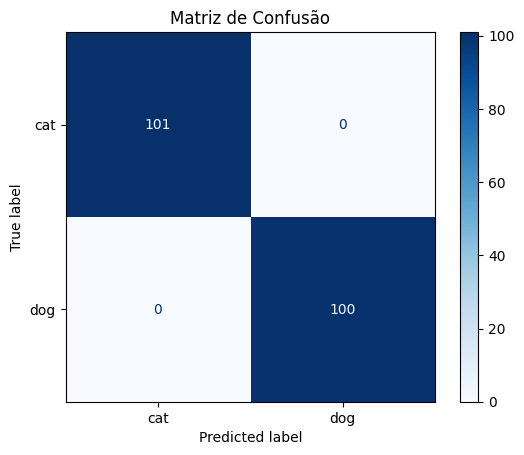

In [14]:
# Gerar a Matriz de Confusão
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images, labels=labels)
        _, predicted = outputs.logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matriz de confusão (0 cat; 1 dog)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat','dog'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

## 3. Deploy e Inferência 🚀

🐾 Classe predita: Gato | Confiança: 99.99%


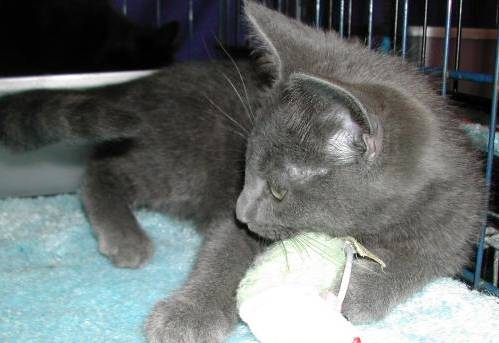

In [15]:
from PIL import Image

# Carregar imagem de teste
test_image_path = './dataset_teste/100.jpg'
image = Image.open(test_image_path)

# Pré-processar
inputs = processor(images=image, return_tensors="pt").to(device)

# Inferência
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()

# Mapeamento para português
traducao = {'cats': 'Gato', 'dogs': 'Cachorro'}

class_names = full_dataset.dataset.classes
label_original = class_names[predicted_class]
predicted_label = traducao.get(label_original, label_original)
confidence = probabilities[0][predicted_class].item()

print(f"🐾 Classe predita: {predicted_label} | Confiança: {confidence:.2%}")
image

### 3.1. Teste com Imagem Local 📷

Saving duno.jpg to duno.jpg
📷 Imagem enviada: duno.jpg
🐾 Classe predita: Cachorro | Confiança: 99.98%


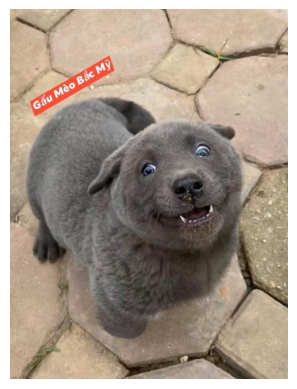

In [16]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Fazer upload de uma imagem do computador
uploaded = files.upload()

# Pegar o nome do arquivo enviado
test_image_path = list(uploaded.keys())[0]

# Abrir imagem
image = Image.open(test_image_path).convert("RGB")

# Pré-processar
inputs = processor(images=image, return_tensors="pt").to(device)

# Inferência
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()

# Mapeamento para português
traducao = {'cats': 'Gato', 'dogs': 'Cachorro'}

# Nomes reais das classes
class_names = full_dataset.dataset.classes
label_original = class_names[predicted_class]
predicted_label = traducao.get(label_original, label_original)
confidence = probabilities[0][predicted_class].item()

print(f"📷 Imagem enviada: {test_image_path}")
print(f"🐾 Classe predita: {predicted_label} | Confiança: {confidence:.2%}")

plt.imshow(image)
plt.axis("off")
plt.show()